# Sequential Decision Making

### Find the shortest path from A to B.

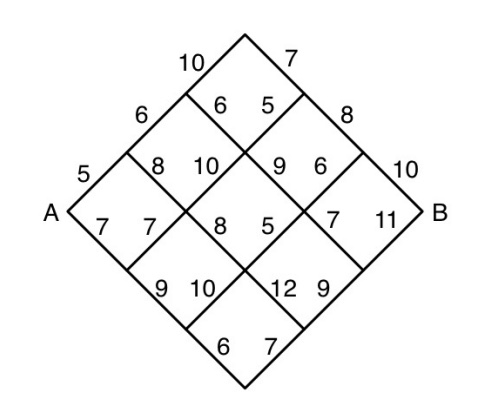

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [172]:
L = 3 # 3 side lengths 
n_cols = 2*L + 1
print(f"n_cols: {n_cols}")

# build state space
state_space = [(0, i) for i in range(n_cols) if i%2==0]
upper_rows = []
for i in range(L):
    for s in state_space:
        add_node = (s[0]+i+1, s[1]+i+1)
        if add_node[0] + add_node[1] < n_cols:
            upper_rows.append(add_node)
lower_rows = [(-u[0], u[1]) for u in upper_rows]
state_space.extend(upper_rows)
state_space.extend(lower_rows)
# print(state_space)

action_space = ["up", "down"]

n_cols: 7


In [184]:
time_map = {
    (0, 0): {"up": 5, "down": 7},
    (1, 1): {"up": 6, "down": 8},
    (-1, 1): {"up": 7, "down": 9},
    (2, 2): {"up": 10, "down": 6},
    (0, 2): {"up": 10, "down": 8},
    (-2, 2): {"up": 10, "down": 6},
    (3, 3): {"down": 7},
    (1, 3): {"up": 5, "down": 9},
    (-1, 3): {"up": 5, "down": 12},
    (-3, 3): {"up": 7},
    (2, 4): {"down": 8},
    (0, 4): {"up": 6, "down": 7},
    (-2, 4): {"up": 9},
    (1, 5): {"down": 10},
    (-1, 5): {"up": 11},
}

def get_next_state(s_current, action):
    """Get the next state given the current state and action."""
    if action == "up":
        s_next = (s_current[0] + 1, s_current[1] + 1)
    elif action == "down":
        s_next = (s_current[0] - 1, s_current[1] + 1)
    if s_next not in state_space:
        raise ValueError(f"Invalid action: {action} at node {s_current}")
    else:
        return s_next

def get_time_to_next_node(s_current, action):
    """Get the time to get from the current state to the next state given an action."""
    return time_map[s_current][action]

def bellman_update(
    value: dict, policy: dict, discount_factor: float = 1.0
) -> tuple[dict, dict]:
    """Perform a Bellman update to update the function table.
    Args:
        value: current value function table
        policy: current policy table
        discount_factor: (optional) discount factor for future rewards
    Returns:
        value_back: updated value function table, one step backward in time
        policy: optimal action for each state

    value_back[s_current] = min over actions of [ sum over s_next of ( reward(s_current, s_next, action) + discount_factor * value[s_next] ) ]
    """

    # initialize the updated value function and policy
    value_back = value.copy()
    
    last_column = max([s[1] for s in state_space])
    bellman_step_num = last_column - min([s[1] for s in value.keys()]) + 1
    print(f"Bellman update step: {bellman_step_num}")

    column = max([s[1] for s in state_space]) - bellman_step_num
    # print(f"\tcolumn: {column}")
    n_rows = bellman_step_num+1

    rows = [s[0] for s in state_space if s[1] == column]
    # print(f"\trows: {rows}")

    possible_values = {}
    for row in rows:
        possible_values[(row, column)] = np.full(2, np.inf) # impossible values will remain nan
    # possible_values = np.full((n_rows, len(action_space)), np.nan) # impossible values will remain nan
        
    # loop over all possible states and actions to compute the value function for each action
    
    for row in rows:
        print(f"\tposition: {(row, column)}")
        for k, action in enumerate(action_space):
            print(f"\t\taction: {action}")
            # compute the value function for each action and fill in the table
            try:
                next_state = get_next_state((row, column), action)
                print(f"\t\t\t{(row, column)} -> {next_state}")
                possible_values[(row, column)][k] = get_time_to_next_node((row, column), action) + discount_factor * value[next_state]
            except ValueError as e:
                print(f"\t\t\t{e}")
                continue
        
        print(f"\t\tpossible values for row {row}: {possible_values[(row, column)]}")

        # choose the action with the minimum time to get to B
        possible_values_this_node = possible_values[(row, column)]
        value_back[(row, column)] = min(possible_values_this_node)
        policy[(row, column)] = action_space[np.argmin(possible_values_this_node)]
        print(f"\t\tpolicy: {policy[(row, column)]}, with value: {min(possible_values_this_node)}", )
    ####### end of add your code here

    return value_back, policy


## Fill out value and policy tables 

In [185]:
V_terminal = {
    (0, 6): 0,
}
value_function = V_terminal # initialize value function with the terminal state
policy = {}
while len(value_function.values()) < len(state_space):
    value_function, policy = bellman_update(value_function, policy)

Bellman update step: 1
	position: (1, 5)
		action: up
			Invalid action: up at node (1, 5)
		action: down
			(1, 5) -> (0, 6)
		possible values for row 1: [inf 10.]
		policy: down, with value: 10.0
	position: (-1, 5)
		action: up
			(-1, 5) -> (0, 6)
		action: down
			Invalid action: down at node (-1, 5)
		possible values for row -1: [11. inf]
		policy: up, with value: 11.0
Bellman update step: 2
	position: (0, 4)
		action: up
			(0, 4) -> (1, 5)
		action: down
			(0, 4) -> (-1, 5)
		possible values for row 0: [16. 18.]
		policy: up, with value: 16.0
	position: (2, 4)
		action: up
			Invalid action: up at node (2, 4)
		action: down
			(2, 4) -> (1, 5)
		possible values for row 2: [inf 18.]
		policy: down, with value: 18.0
	position: (-2, 4)
		action: up
			(-2, 4) -> (-1, 5)
		action: down
			Invalid action: down at node (-2, 4)
		possible values for row -2: [20. inf]
		policy: up, with value: 20.0
Bellman update step: 3
	position: (1, 3)
		action: up
			(1, 3) -> (2, 4)
		action: down

In [166]:
state = (0, 0) # initial state
time_list = []

for k in range(n_cols-1):
        # choose action with optimal policy
        action = policy[state]

        # transition to next state and record time to get there
        next_state = get_next_state(state, action)
        time = get_time_to_next_node(state, action)

        # store time at each step
        time_list.append(time)

        # print ts
        if k == 0:
            print("Initial State: ", state)
            print("Expected Time: ", value_function[state])
            print("...................................")
                
        print("State: ", state)
        print("\tAction:\t\t\t", action)
        print("\tTime:\t\t\t", time)
        print("\tTot. time this trial:\t", sum(time_list), "\n")

        state = next_state
        if k == n_cols-2:
            print("State: ", state)

Initial State:  (0, 0)
Expected Time:  40.0
...................................
State:  (0, 0)
	Action:			 up
	Time:			 5
	Tot. time this trial:	 5 

State:  (1, 1)
	Action:			 up
	Time:			 6
	Tot. time this trial:	 11 

State:  (2, 2)
	Action:			 down
	Time:			 6
	Tot. time this trial:	 17 

State:  (1, 3)
	Action:			 up
	Time:			 5
	Tot. time this trial:	 22 

State:  (2, 4)
	Action:			 down
	Time:			 8
	Tot. time this trial:	 30 

State:  (1, 5)
	Action:			 down
	Time:			 10
	Tot. time this trial:	 40 

State:  (0, 6)


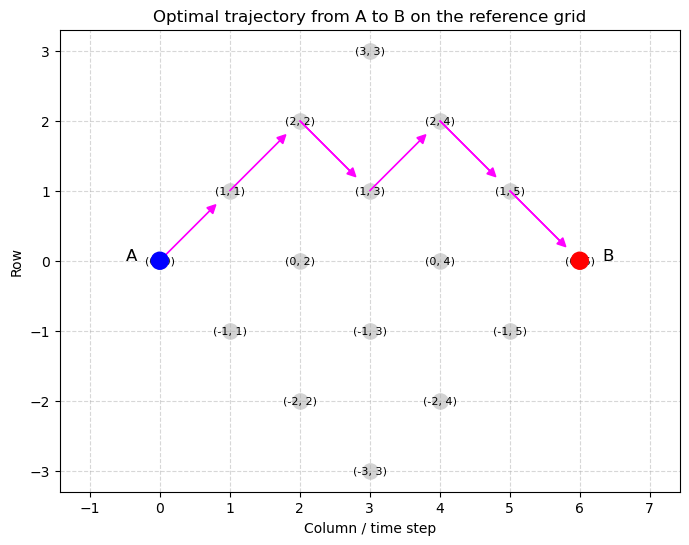

In [171]:
import matplotlib.pyplot as plt

start = (0, 0)
goal = (0, n_cols - 1)

trajectory = [start]
state = start
while state != goal:
    state = get_next_state(state, policy[state])
    trajectory.append(state)

grid_x = [s[1] for s in state_space]
grid_y = [s[0] for s in state_space]

traj_x = [s[1] for s in trajectory]
traj_y = [s[0] for s in trajectory]

plt.figure(figsize=(8, 6))
plt.scatter(grid_x, grid_y, color="lightgray", s=120, zorder=1)

for s in state_space:
    plt.text(s[1], s[0], f"{s}", ha="center", va="center", fontsize=8, zorder=2)

# plt.plot(traj_x, traj_y, marker="o", color="red", linewidth=2, zorder=3)

for i in range(len(trajectory) - 1):
    dx = traj_x[i + 1] - traj_x[i]
    dy = traj_y[i + 1] - traj_y[i]
    plt.arrow(
        traj_x[i],
        traj_y[i],
        dx * 0.8,
        dy * 0.8,
        head_width=0.12,
        head_length=0.12,
        fc="magenta",
        ec="magenta",
        length_includes_head=True,
        zorder=4,
    )

plt.scatter([start[1], goal[1]], [start[0], goal[0]], color=["blue", "red"], s=150, zorder=5)
plt.text(start[1] - 0.4, start[0], "A", fontsize=12, ha="center")
plt.text(goal[1] + 0.4, goal[0], "B", fontsize=12, ha="center")

plt.title("Optimal trajectory from A to B on the reference grid")
plt.xlabel("Column / time step")
plt.ylabel("Row")
plt.grid(True, linestyle="--", alpha=0.5)
plt.axis("equal")
plt.show()

## Part (b) - computational complexity

The 